# From flat noise to a bell curve: the Central Limit Theorem

If you take a bunch of numbers drawn from a **flat, uniform**
distribution — every value between $x_{low}$ and $x_{high}$ equally likely — and you repeatedly average
groups of $N$ of them, the *averages themselves* pile up into a smooth bell-shaped curve. Not a flat curve
like the one you started with.

This is the **Central Limit Theorem (CLT)**, and it's one of the reasons the normal (Gaussian) distribution
shows up everywhere in statistics and physics — measurement noise, dice rolls, exam scores, detector
resolutions — almost regardless of what the underlying random process actually looks like.

This notebook builds that phenomenon from scratch:

1. Draw $N$ uniform random numbers and take their mean; repeat this many times and collect the means in a list.
2. Watch the shape of that list's histogram evolve as we collect more means, and as we average more numbers per mean.
3. Fit a Gaussian to it and check that the fitted parameters match what theory predicts.
4. Highlight what makes a Gaussian a Gaussian.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

rng = np.random.default_rng(42)  # fixed seed so the notebook is reproducible


## 2. The underlying distribution

We'll draw individual numbers uniformly from the range $[x_{low}, x_{high}]$ — meaning every value in that
range is equally likely. Nothing bell-shaped about this at all; a histogram of raw draws should look flat.

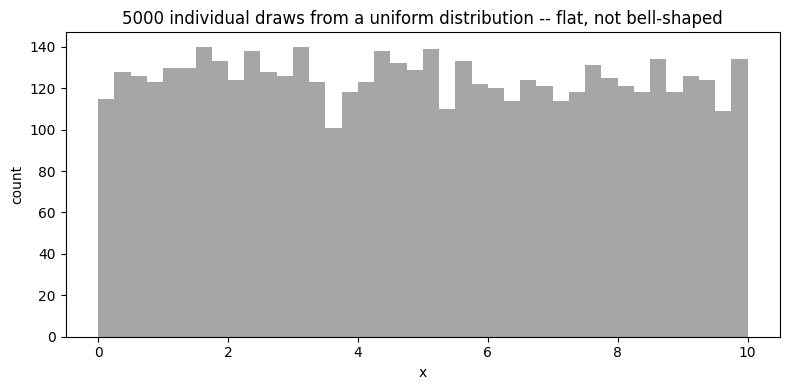

In [2]:
x_low, x_high = 0.0, 10.0

raw = rng.uniform(x_low, x_high, 5000)

plt.figure(figsize=(8, 4))
plt.hist(raw, bins=40, range=(x_low, x_high), color='gray', alpha=0.7)
plt.xlabel('x')
plt.ylabel('count')
plt.title('5000 individual draws from a uniform distribution -- flat, not bell-shaped')
plt.tight_layout()
plt.show()


A uniform distribution on $[x_{low}, x_{high}]$ has two properties worth keeping in mind, because
we'll check our results against them later:

$$\mu_x = \frac{x_{low}+x_{high}}{2} \qquad\qquad \sigma_x = \frac{x_{high}-x_{low}}{\sqrt{12}}$$

## 3. Generating the list of means

Now the actual recipe: draw $N$ random numbers, average them into a single number, and repeat that whole
process `n_experiments` times, collecting every average into a list called `means`.

In [11]:
def sample_means(n_experiments, N, x_low, x_high):
    """Run n_experiments independent experiments; each draws N uniform randoms and keeps their mean."""
    means = []
    for _ in range(n_experiments):
        sample = rng.uniform(x_low, x_high, N)
        means.append(sample.mean())
    return np.array(means)

# a single quick example: 50 numbers per experiment, one experiment
one_mean = sample_means(n_experiments=1, N=50, x_low=x_low, x_high=x_high)
print('One experiment, N=50 numbers averaged into a single value:', one_mean)


One experiment, N=50 numbers averaged into a single value: [5.0516078]


## 4. Watching the bell curve emerge

A single mean is just one number — you can't see a "shape" in one point. The shape only appears once you
collect *many* means. Let's fix $N=50$ (numbers averaged per experiment) and vary how many experiments we
run: 1, 10, 50, 100, 1000, 5000, 10000.

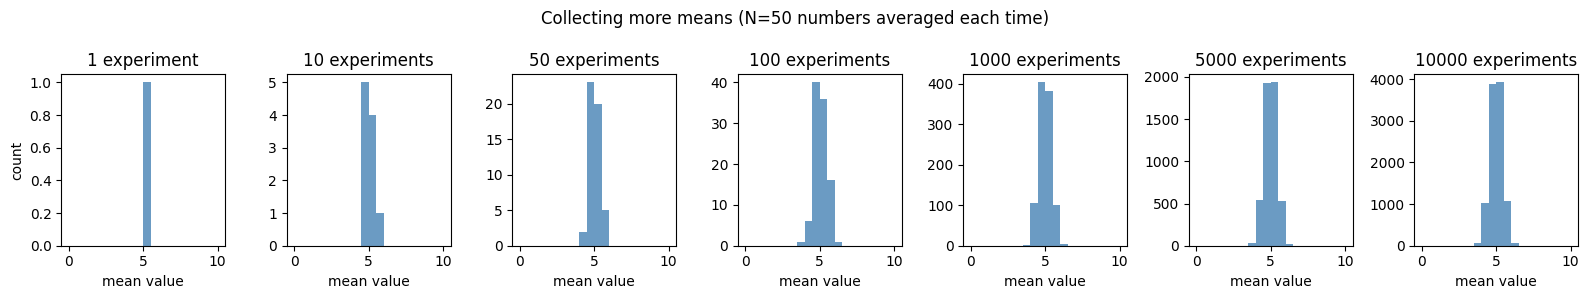

In [12]:
N_fixed = 50
experiment_counts = [1, 10, 50, 100, 1000, 5000, 10000]

fig, axes = plt.subplots(1, len(experiment_counts), figsize=(16, 3), sharex=True, sharey=False)
for ax, n_exp in zip(axes, experiment_counts):
    means = sample_means(n_exp, N_fixed, x_low, x_high)
    ax.hist(means, bins=20, range=(x_low, x_high), color='steelblue', alpha=0.8)
    ax.set_title(f'{n_exp} experiment' + ('s' if n_exp > 1 else ''))
    ax.set_xlabel('mean value')
axes[0].set_ylabel('count')
plt.suptitle(f'Collecting more means (N={N_fixed} numbers averaged each time)')
plt.tight_layout()
plt.show()


With only 1 or 10 experiments there's nothing to see — just a few scattered points. By 100–1000
experiments a clear bell shape has emerged, centered around the midpoint of $[x_{low},x_{high}]$ and
noticeably narrower than the flat distribution we started with. **Running more experiments doesn't change
the shape of the underlying phenomenon — it just fills in a histogram that was always going to look this
way, with enough samples to reveal it.**

## 5. What happens if we average more (or fewer) numbers per mean?

Fix a large number of experiments (so the histogram is always well populated)
and instead vary $N$, the count of numbers averaged into each mean.


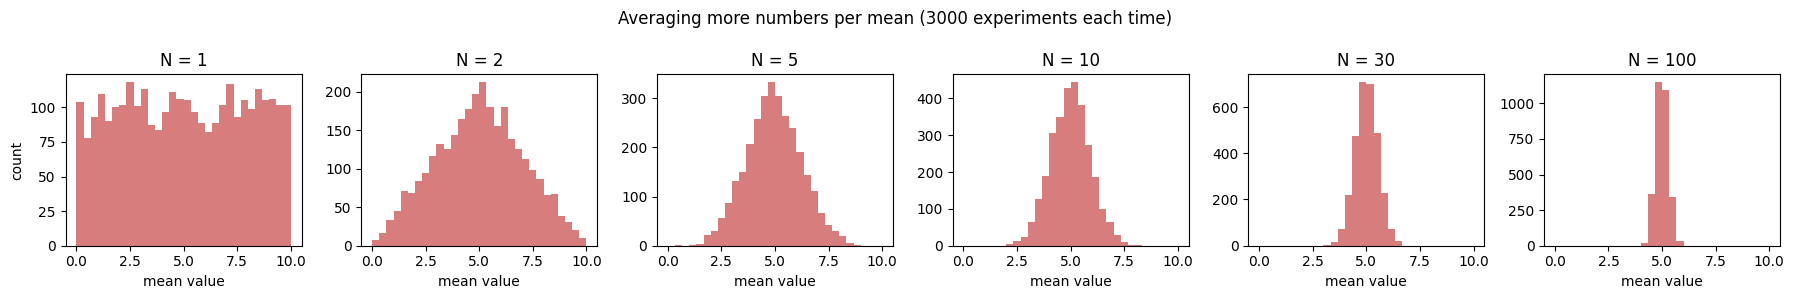

In [13]:
n_experiments_fixed = 3000
N_values = [1, 2, 5, 10, 30, 100]

fig, axes = plt.subplots(1, len(N_values), figsize=(18, 3), sharex=True, sharey=False)
for ax, N in zip(axes, N_values):
    means = sample_means(n_experiments_fixed, N, x_low, x_high)
    ax.hist(means, bins=30, range=(x_low, x_high), color='indianred', alpha=0.8)
    ax.set_title(f'N = {N}')
    ax.set_xlabel('mean value')
axes[0].set_ylabel('count')
plt.suptitle(f'Averaging more numbers per mean ({n_experiments_fixed} experiments each time)')
plt.tight_layout()
plt.show()


Two things happen as $N$ grows:

- **The distribution narrows.** Averaging more numbers cancels out more of the randomness, so the mean
  lands closer to the true center more consistently.
- **The shape becomes more Gaussian.** Even at $N=2$ it's already triangular, not flat; by $N=10$–$30$ it's
  a convincing bell curve.

Notice $N=1$ is special: the "mean" of one number *is* that number, so its histogram is just the original
flat uniform distribution. The bell shape is not present in the data itself — it's an emergent property of
averaging **more than one** random draw.

## 6. Fitting a Gaussian to the means

Time to make this quantitative. We'll generate one large set of means and fit it with an explicit Gaussian
function

$$G(x;A,\mu,\sigma) = A\exp\!\left[-\tfrac12\left(\frac{x-\mu}{\sigma}\right)^2\right]$$

using a least-squares fit to the histogram, then compare the fitted $\mu$ and $\sigma$ to what theory
predicts.

In [16]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

N = 50
n_experiments = 5000
means = sample_means(n_experiments, N, x_low, x_high)

nbins = 40
counts, edges = np.histogram(means, bins=nbins)
centers = 0.5 * (edges[:-1] + edges[1:])

# initial guesses: peak height, sample mean, sample std
p0 = [counts.max(), means.mean(), means.std()]
popt, pcov = curve_fit(gaussian, centers, counts, p0=p0)
A_fit, mu_fit, sigma_fit = popt
mu_err, sigma_err = np.sqrt(np.diag(pcov))[1], np.sqrt(np.diag(pcov))[2]

print(f'Fitted mu    = {mu_fit:.3f} +/- {mu_err:.3f}')
print(f'Fitted sigma = {sigma_fit:.3f} +/- {sigma_err:.3f}')


Fitted mu    = 4.997 +/- 0.004
Fitted sigma = 0.408 +/- 0.004


### Comparing the fit to theory

The Central Limit Theorem makes an exact prediction for both parameters:

$$\mu_{\rm mean} = \mu_x = \frac{x_{low}+x_{high}}{2} \qquad\qquad \sigma_{\rm mean} = \frac{\sigma_x}{\sqrt{N}} = \frac{x_{high}-x_{low}}{\sqrt{12N}}$$

The mean of the means should match the mean of a single draw — averaging doesn't shift where you're
centered. The *spread* shrinks with $\sqrt{N}$ following the poissonian distribution for counting experiments. This $1/\sqrt{N}$ law is exactly why, e.g., a detector needs 4x the data to halve its uncertainty.

In [17]:
mu_theory = (x_low + x_high) / 2
sigma_x_theory = (x_high - x_low) / np.sqrt(12)
sigma_mean_theory = sigma_x_theory / np.sqrt(N)

print(f'Theory:  mu    = {mu_theory:.3f}')
print(f'Theory:  sigma = {sigma_mean_theory:.3f}   (single-draw sigma = {sigma_x_theory:.3f}, divided by sqrt(N={N}))')
print()
print(f'Fit:     mu    = {mu_fit:.3f} +/- {mu_err:.3f}')
print(f'Fit:     sigma = {sigma_fit:.3f} +/- {sigma_err:.3f}')


Theory:  mu    = 5.000
Theory:  sigma = 0.408   (single-draw sigma = 2.887, divided by sqrt(N=50))

Fit:     mu    = 4.997 +/- 0.004
Fit:     sigma = 0.408 +/- 0.004


## 7. The final picture, with the Gaussian's defining properties

A Gaussian is fully described by just two numbers, $\mu$ (where it's centered) and $\sigma$ (how wide it
is), and it always obeys the same **68-95-99.7 rule**: about 68% of values fall within $\pm1\sigma$ of the
mean, 95% within $\pm2\sigma$, and 99.7% within $\pm3\sigma$ — regardless of what $\mu$ and $\sigma$
actually are. Let's overlay the fit and shade those regions.

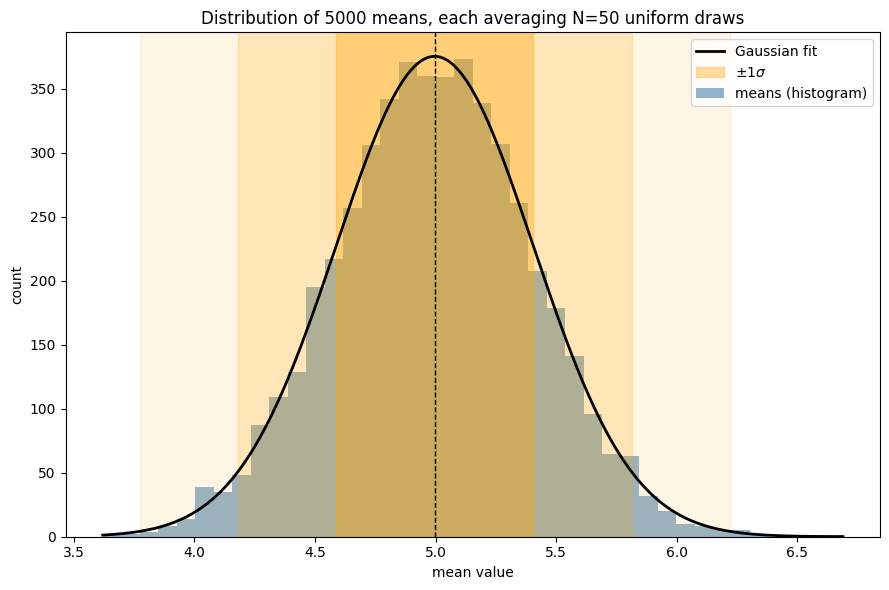

Fraction of means within 1 sigma: 0.683  (expect ~0.683)
Fraction of means within 2 sigma: 0.955  (expect ~0.954)
Fraction of means within 3 sigma: 0.997  (expect ~0.997)


In [18]:
plt.figure(figsize=(9, 6))
plt.bar(centers, counts, width=(edges[1]-edges[0]), color='steelblue', alpha=0.6, label='means (histogram)')

xx = np.linspace(means.min(), means.max(), 400)
plt.plot(xx, gaussian(xx, *popt), 'k-', lw=2, label='Gaussian fit')

for k, alpha in zip([1, 2, 3], [0.35, 0.20, 0.10]):
    plt.axvspan(mu_fit - k*sigma_fit, mu_fit + k*sigma_fit, color='orange', alpha=alpha,
                label=f'$\\pm{k}\\sigma$' if k == 1 else None)

plt.axvline(mu_fit, color='k', ls='--', lw=1)
plt.xlabel('mean value')
plt.ylabel('count')
plt.title(f'Distribution of {n_experiments} means, each averaging N={N} uniform draws')
plt.legend()
plt.tight_layout()
plt.show()

within_1s = np.mean(np.abs(means - mu_fit) <= sigma_fit)
within_2s = np.mean(np.abs(means - mu_fit) <= 2*sigma_fit)
within_3s = np.mean(np.abs(means - mu_fit) <= 3*sigma_fit)
print(f'Fraction of means within 1 sigma: {within_1s:.3f}  (expect ~0.683)')
print(f'Fraction of means within 2 sigma: {within_2s:.3f}  (expect ~0.954)')
print(f'Fraction of means within 3 sigma: {within_3s:.3f}  (expect ~0.997)')


## 8. Takeaways

- The **shape** (bell curve) comes from averaging *more than one* random number together — it's a property
  of the averaging process, not of the underlying uniform distribution, which stays flat.
- The **center** of the bell curve matches the mean of the original distribution — averaging doesn't bias
  where you land.
- The **width** shrinks as $1/\sqrt{N}$ — averaging more numbers gives you a more precise estimate of the
  true mean, but with strongly diminishing returns (4x the data only halves the uncertainty).
- **Running more experiments** doesn't change any of this — it only reveals the shape more clearly, the
  same way rolling a fair die more times doesn't change its odds, just your ability to measure them.
- This works for (almost) *any* starting distribution, not just uniform — the same procedure applied to
  dice rolls, exam scores, or detector noise converges to the same bell curve. That universality is the
  heart of the Central Limit Theorem, and it's why the Gaussian distribution is the default assumption for
  "random noise" throughout statistics and physics.